<div align="center">

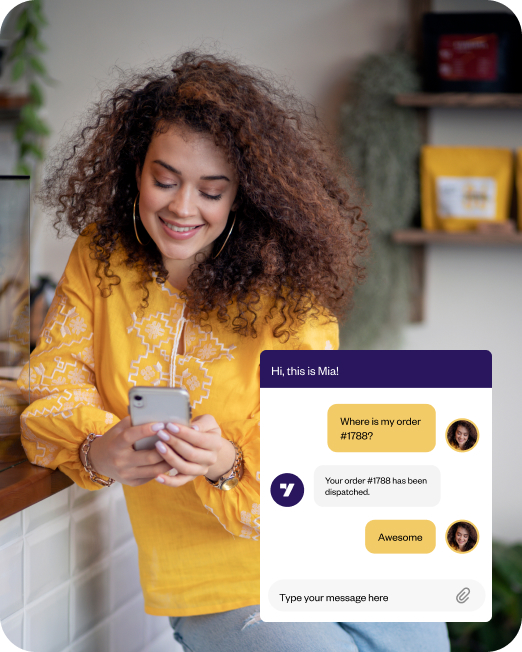

</div>


<div align="center">

# 🛒🤖 **IndustryGPT: Retail E-commerce Customer Support Bot**

## **Qwen2.5 3B Instruct + QLoRA 4-bit Fine-Tuning**

### 📦 **Industry:** Retail and E-commerce &nbsp; | &nbsp; 🧠 **Model:** Qwen/Qwen2.5-3B-Instruct &nbsp; | &nbsp; 💾 **Storage:** Google Drive

</div>

---

## 🌟 **Project Summary**

This project builds a practical customer-support chatbot for the **Retail and E-commerce** industry. The main idea is to take a strong pre-trained language model and adapt it to the type of questions customers usually ask in online shopping platforms. The chatbot is trained to respond to support topics such as damaged orders, refunds, delivery tracking, delayed orders, failed payments, returns, exchanges, invoices, account access, complaints, and address changes. A general chatbot may answer these questions, but it can also make up details such as fake phone numbers, websites, exact order status, or payment options. This project handles that issue by fine-tuning the model on domain-specific customer-support examples and by using a safety instruction that keeps the answers focused on practical support guidance.

The selected model is **Qwen/Qwen2.5-3B-Instruct**, and the fine-tuning method is **QLoRA 4-bit**. QLoRA makes the project possible on Google Colab because the large base model is loaded in a memory-efficient format while only a smaller LoRA adapter is trained. The trained adapter is then saved permanently in **Google Drive**, which is the most important workflow improvement in this final notebook. After the first successful full run, the training does not need to be repeated again. For later testing or demo sessions, only the setup and loading cells are needed: **Code Cell 01, Code Cell 02, Code Cell 03, Code Cell 13, and Code Cell 16**. If evaluation output is needed again, **Code Cell 14 and Code Cell 15** can also be run.

<div align="center">

### 🚀 **One-Time Training, Reusable Chatbot**

| Stage | What happens | Need to run again? |
|---|---|---|
| **First full run** | Train Qwen with QLoRA and save adapter to Drive | ✅ Yes, only once |
| **Later demo run** | Load base Qwen and attach saved adapter | ✅ Yes |
| **Training again** | Repeat fine-tuning from scratch | ❌ No, unless changing dataset/settings |
| **Chatbot UI** | Launch Gradio and ask questions | ✅ Yes |

</div>

---

## ✅ **How this notebook matches the capstone requirements**

| Requirement | What this project does |
|---|---|
| **Industry Selection** | Focuses on Retail and E-commerce customer support |
| **Data Collection** | Uses a public Hugging Face customer-support dataset |
| **Data Cleaning** | Removes noisy text, unsafe sensitive patterns, fake contact details, and unusable rows |
| **Model Selection** | Uses Qwen2.5 3B Instruct from Hugging Face |
| **Fine-Tuning** | Applies QLoRA 4-bit supervised fine-tuning in Google Colab |
| **Bot Development** | Builds an interactive Gradio chatbot for live testing |
| **Evaluation** | Compares base Qwen and fine-tuned Qwen on common support questions |
| **Persistence** | Saves the trained LoRA adapter in Google Drive for reuse |

---

## 🧭 **Code Cell Index**

| Cell | Purpose |
|---|---|
| **Code Cell 01** | Install required libraries |
| **Code Cell 02** | Mount Google Drive and create final project folders |
| **Code Cell 03** | Set model, training settings, and safety instruction |
| **Code Cell 04** | Load the customer-support dataset |
| **Code Cell 05** | Inspect dataset quality |
| **Code Cell 06** | Clean data and remove problematic rows |
| **Code Cell 07** | Show cleaned data summary and samples |
| **Code Cell 08** | Convert data into Qwen chat format |
| **Code Cell 09** | Load Qwen2.5 3B in 4-bit and attach LoRA |
| **Code Cell 10** | Configure QLoRA trainer |
| **Code Cell 11** | Train, resume, or skip if adapter already exists |
| **Code Cell 12** | Verify saved adapter files |
| **Code Cell 13** | Load saved adapter for inference |
| **Code Cell 14** | Compare base Qwen and fine-tuned Qwen |
| **Code Cell 15** | Save evaluation CSV and run summary |
| **Code Cell 16** | Launch Gradio chatbot UI |

In [ ]:
# Code Cell 01: Install required libraries.
# This cell installs the libraries needed for dataset loading, QLoRA training, model loading, and Gradio UI.
!pip -q install -U transformers accelerate datasets peft trl bitsandbytes sentencepiece pandas scikit-learn gradio safetensors

print("Code Cell 01 completed: required libraries are installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires panda

In [ ]:
# Code Cell 02: Mount Google Drive and create final project folders.
# pathlib keeps folder paths readable and avoids manual string joining.
from pathlib import Path

# json saves summaries and settings in a reusable format.
import json

# re helps clean text patterns such as emails, URLs, and repeated spaces.
import re

# random keeps sampling stable across runs.
import random

# datetime stores when the run was created.
from datetime import datetime

# numpy helps set a stable random seed.
import numpy as np

# pandas is used for dataset inspection, cleaning, and evaluation tables.
import pandas as pd

# torch runs the model and checks GPU availability.
import torch

# Dataset and load_dataset come from Hugging Face Datasets.
from datasets import Dataset, load_dataset

# Transformers classes load the tokenizer, model, quantization config, and training arguments.
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments

# This helper finds the latest checkpoint when training needs to resume.
from transformers.trainer_utils import get_last_checkpoint

# PEFT classes attach and reload LoRA adapters.
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training

# TRL provides SFTTrainer for supervised instruction fine-tuning.
try:
    from trl import SFTTrainer, SFTConfig
except ImportError:
    from trl import SFTTrainer
    SFTConfig = None

# Google Drive mount is needed because Colab storage disappears after disconnect.
from google.colab import drive

# This path exists only when Google Drive is mounted correctly.
my_drive_path = Path("/content/drive/MyDrive")

# Mount Drive only when MyDrive is not already available.
if not my_drive_path.exists():
    drive.mount("/content/drive", force_remount=True)
else:
    print("Google Drive is already available.")

# Stop early if Drive is still not available, because saving to local Colab would be unsafe.
if not my_drive_path.exists():
    raise RuntimeError("Google Drive is not mounted. Please mount Drive before continuing.")

# This is the main Drive project folder used by all v5 cells.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models")

# These folders keep the final project organized.
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks_final"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

# These v5 folders store checkpoints, final adapter, and evaluation outputs.
CHECKPOINT_DIR = MODELS_DIR / "v5_qwen25_checkpoints"
ADAPTER_DIR = MODELS_DIR / "v5_qwen25_final_adapter"
EVAL_DIR = OUTPUTS_DIR / "v5_eval_results"

# Create every folder safely without deleting anything.
for folder in [NOTEBOOKS_DIR, MODELS_DIR, OUTPUTS_DIR, CHECKPOINT_DIR, ADAPTER_DIR, EVAL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Make pandas tables easier to read in Colab.
pd.set_option("display.max_colwidth", 260)

# Set one seed so sampling and splits stay stable.
SEED = 42

# Apply the seed to Python random.
random.seed(SEED)

# Apply the seed to NumPy.
np.random.seed(SEED)

# Apply the seed to PyTorch.
torch.manual_seed(SEED)

# Print proof that the folder setup worked.
print("Code Cell 02 completed: Drive is mounted and v5 folders are ready.")
print("Project root:", PROJECT_ROOT)
print("Checkpoint folder:", CHECKPOINT_DIR)
print("Adapter folder:", ADAPTER_DIR)
print("Evaluation folder:", EVAL_DIR)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Code Cell 02 completed: Drive is mounted and v5 folders are ready.
Project root: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models
Checkpoint folder: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_checkpoints
Adapter folder: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter
Evaluation folder: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/outputs/v5_eval_results
CUDA available: True
GPU: Tesla T4


In [ ]:
# Code Cell 03: Set model, training settings, and safety instruction.
# This is the pre-trained model selected from Hugging Face.
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

# This public dataset contains customer-support instruction and response pairs.
DATASET_NAME = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# Start with a Colab-friendly training size to avoid quota and runtime failures.
MAX_TRAIN_EXAMPLES = 2500

# Keep evaluation small because the main goal is demo quality and comparison.
MAX_EVAL_EXAMPLES = 100

# One epoch is enough for a practical capstone demo with limited GPU quota.
EPOCHS = 1

# A 512-token limit keeps training faster and avoids memory pressure.
MAX_SEQ_LENGTH = 512

# BF16 is used only when the GPU supports it.
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

# FP16 is used on T4-style GPUs where BF16 is not supported.
USE_FP16 = torch.cuda.is_available() and not USE_BF16

# This prompt controls safety and prevents fake exact business data.
SYSTEM_PROMPT = (
    "You are a polite retail e-commerce customer support assistant. "
    "Answer only the customer's support question. "
    "Give clear practical guidance. "
    "Do not invent phone numbers, websites, exact order status, exact refund status, prices, or private records. "
    "Do not ask for passwords, OTPs, CVV, full card numbers, or login credentials. "
    "If private order data is needed, guide the customer to the account, order, payment, or help section."
)

# These settings are saved so the run can be understood later.
training_settings = {
    "model_name": MODEL_NAME,
    "dataset_name": DATASET_NAME,
    "max_train_examples": MAX_TRAIN_EXAMPLES,
    "max_eval_examples": MAX_EVAL_EXAMPLES,
    "epochs": EPOCHS,
    "max_seq_length": MAX_SEQ_LENGTH,
    "use_bf16": USE_BF16,
    "use_fp16": USE_FP16,
    "system_prompt": SYSTEM_PROMPT,
}

# Save the settings before training so the run is documented even if Colab disconnects later.
settings_path = EVAL_DIR / "v5_training_settings.json"
settings_path.write_text(json.dumps(training_settings, indent=2), encoding="utf-8")

# Print the final settings for the notebook record.
print("Code Cell 03 completed: model and training settings are ready.")
print(json.dumps(training_settings, indent=2))
print("Settings saved to:", settings_path)

Code Cell 03 completed: model and training settings are ready.
{
  "model_name": "Qwen/Qwen2.5-3B-Instruct",
  "dataset_name": "bitext/Bitext-customer-support-llm-chatbot-training-dataset",
  "max_train_examples": 2500,
  "max_eval_examples": 100,
  "epochs": 1,
  "max_seq_length": 512,
  "use_bf16": true,
  "use_fp16": false,
  "system_prompt": "You are a polite retail e-commerce customer support assistant. Answer only the customer's support question. Give clear practical guidance. Do not invent phone numbers, websites, exact order status, exact refund status, prices, or private records. Do not ask for passwords, OTPs, CVV, full card numbers, or login credentials. If private order data is needed, guide the customer to the account, order, payment, or help section."
}
Settings saved to: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/outputs/v5_eval_results/v5_training_settings.json


In [ ]:
# Code Cell 04: Load the customer-support dataset.
# Download the dataset from Hugging Face.
dataset = load_dataset(DATASET_NAME)

# Convert the training split into a pandas dataframe for cleaning.
raw_df = dataset["train"].to_pandas()

# Print a clear loading summary.
print("Code Cell 04 completed: dataset loaded.")
print(dataset)
print("Raw rows:", len(raw_df))
print("Columns:", list(raw_df.columns))

# Show the first rows so the dataset structure is visible.
display(raw_df.head(5))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Code Cell 04 completed: dataset loaded.
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})
Raw rows: 26872
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,"I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you."
1,BQZ,i have a question about cancelling oorder {{Order Number}},ORDER,cancel_order,"I've been informed that you have a question about canceling order {{Order Number}}. I'm here to assist you! Please go ahead and let me know what specific question you have, and I'll provide you with all the information and guidance you need. Your satisfact..."
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,"I can sense that you're seeking assistance with canceling your purchase with the purchase number {{Order Number}}. I apologize for any inconvenience caused, and I'm here to guide you through the process.\n\nTo cancel your purchase, please follow these step..."
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,"I understood that you need assistance with canceling your purchase with the order number {{Order Number}}. We apologize for any inconvenience this may have caused. To initiate the cancellation process, please follow these steps:\n\n1. Sign in to your accou..."
4,BCELN,"I cannot afford this order, cancel purchase {{Order Number}}",ORDER,cancel_order,"I'm sensitive to the fact that you're facing financial difficulties and need to cancel your purchase with the order number {{Order Number}}. We're here to assist you with that, and I appreciate your transparency in sharing your situation with us. Let's pro..."


In [ ]:
# Code Cell 05: Inspect dataset quality.
# Count missing values in each column.
missing_values = raw_df.isna().sum().rename("missing_values").reset_index().rename(columns={"index": "column"})

# Count rows by support category.
category_counts = raw_df["category"].value_counts(dropna=False).rename_axis("category").reset_index(name="rows")

# Count rows by support intent.
intent_counts = raw_df["intent"].value_counts(dropna=False).rename_axis("intent").reset_index(name="rows")

# Print inspection results for the notebook record.
print("Code Cell 05 completed: dataset inspection is ready.")
print("Raw rows:", len(raw_df))
print("Unique categories:", raw_df["category"].nunique())
print("Unique intents:", raw_df["intent"].nunique())

# Display missing value table.
display(missing_values)

# Display category distribution.
display(category_counts)

# Display top intent distribution.
display(intent_counts.head(30))

Code Cell 05 completed: dataset inspection is ready.
Raw rows: 26872
Unique categories: 11
Unique intents: 27


,column,missing_values
0,flags,0
1,instruction,0
2,category,0
3,intent,0
4,response,0


,category,rows
0,ACCOUNT,5986
1,ORDER,3988
2,REFUND,2992
3,INVOICE,1999
4,CONTACT,1999
5,PAYMENT,1998
6,FEEDBACK,1997
7,DELIVERY,1994
8,SHIPPING,1970
9,SUBSCRIPTION,999


,intent,rows
0,check_invoice,1000
1,complaint,1000
2,contact_customer_service,1000
3,edit_account,1000
4,switch_account,1000
5,check_payment_methods,999
6,contact_human_agent,999
7,delivery_period,999
8,get_invoice,999
9,newsletter_subscription,999


In [ ]:
# Code Cell 06: Clean data and remove problematic rows.
# These replacements keep useful placeholder meaning without inventing real private data.
PLACEHOLDER_REPLACEMENTS = {
    "{{Order Number}}": "the order",
    "{{Invoice Number}}": "the invoice",
    "{{Online Order Interaction}}": "My Orders section",
    "{{Online Payment Interaction}}": "Payment section",
    "{{Online Navigation Step}}": "Help section",
    "{{Online Customer Support Channel}}": "support channel",
    "{{Live Chat Support}}": "support chat",
    "{{Profile}}": "profile",
    "{{Profile Type}}": "profile type",
    "{{Settings}}": "Settings section",
    "{{Online Company Portal Info}}": "account page",
    "{{Date}}": "the date",
    "{{Date Range}}": "the selected date range",
    "{{Shipping Cut-off Time}}": "shipping cut-off time",
    "{{Delivery City}}": "delivery city",
    "{{Delivery Country}}": "delivery country",
    "{{Customer Support Phone Number}}": "customer support channel",
    "{{Customer Support Email}}": "customer support channel",
    "{{Website URL}}": "the website",
    "{{Email Address}}": "registered email address",
    "{{Password}}": "password reset option",
    "{{Salutation}}": "",
    "{{Client First Name}}": "",
    "{{Client Last Name}}": "",
    "{{Account Type}}": "account type",
    "{{Account Category}}": "account category",
    "{{Account Change}}": "account change",
    "{{Program}}": "program",
    "{{Refund Amount}}": "refund amount",
    "{{Money Amount}}": "amount",
    "{{Store Location}}": "store location",
}

# This pattern removes any placeholder that was not listed above.
PLACEHOLDER_PATTERN = re.compile(r"\{\{[^{}]+\}\}")

# This pattern removes real-looking phone numbers from text.
PHONE_PATTERN = re.compile(r"(\+?\d[\d\s().-]{7,}\d)")

# This pattern removes real-looking email addresses from text.
EMAIL_PATTERN = re.compile(r"\b[\w.+-]+@[\w-]+(?:\.[\w-]+)+\b")

# This pattern removes real-looking web links from text.
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)

# This pattern flags profane rows.
PROFANE_PATTERN = re.compile(r"\b(fuck|fucking|shit|bitch|asshole|bastard)\b|f\*", flags=re.IGNORECASE)

# This pattern flags unsafe requests that should not be learned by the bot.
SENSITIVE_PATTERN = re.compile(r"\b(otp|cvv|full card number|credit card number|share password|send password|login credentials)\b", flags=re.IGNORECASE)

# These phrases often made the model sound odd, so rows with them are removed.
BAD_STYLE_PATTERN = re.compile(
    r"\b(i'm sensitive to|i catch on|i pick up what you're putting down|"
    r"i'm on the same wavelength|unquestionably|i decoded|i've decoded|"
    r"i grasp your situation|i'm cognizant|always good to connect|i'm attuned|"
    r"i'm aligned|i've realized)\b",
    flags=re.IGNORECASE,
)


# Return an empty string for missing values.
def text_or_empty(value):
    if value is None or pd.isna(value):
        return ""
    return str(value)


# Replace placeholders, remove fake/private contact details, and normalize spacing.
def clean_text(value):
    text = text_or_empty(value)
    for placeholder, replacement in PLACEHOLDER_REPLACEMENTS.items():
        text = text.replace(placeholder, replacement)
    text = PLACEHOLDER_PATTERN.sub("", text)
    text = PHONE_PATTERN.sub("", text)
    text = EMAIL_PATTERN.sub("", text)
    text = URL_PATTERN.sub("", text)
    text = text.replace('""', "")
    text = re.sub(r"\bat\s*[.]", ".", text)
    text = re.sub(r"\bthe or the order\b", "the order", text, flags=re.IGNORECASE)
    text = re.sub(r"\bthe the\b", "the", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Keep answers readable and short enough for a demo chatbot.
def clean_answer(value):
    text = clean_text(value)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    kept = []
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
        kept.append(sentence)
        if len(kept) >= 5:
            break
    text = " ".join(kept)
    text = re.sub(r"\b1\.\s*2\.", "1.", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Copy the raw data so the original dataframe stays unchanged.
work_df = raw_df.copy()

# Clean the customer question.
work_df["question"] = work_df["instruction"].apply(clean_text)

# Clean the assistant response.
work_df["answer"] = work_df["response"].apply(clean_answer)

# Count words in the cleaned question.
work_df["question_words"] = work_df["question"].str.split().str.len()

# Count words in the cleaned answer.
work_df["answer_words"] = work_df["answer"].str.split().str.len()

# Combine raw text fields for row-level filtering.
combined_text = work_df["instruction"].apply(text_or_empty) + " " + work_df["response"].apply(text_or_empty)

# Mark rows that contain profanity.
work_df["drop_profanity"] = combined_text.apply(lambda text: bool(PROFANE_PATTERN.search(text)))

# Mark rows that contain unsafe sensitive patterns.
work_df["drop_sensitive"] = combined_text.apply(lambda text: bool(SENSITIVE_PATTERN.search(text)))

# Mark rows that contain odd style patterns.
work_df["drop_bad_style"] = work_df["response"].apply(lambda text: bool(BAD_STYLE_PATTERN.search(text_or_empty(text))))

# Mark rows where cleaned answers are too long for the demo.
work_df["drop_too_long"] = work_df["answer_words"] > 110

# Mark rows where cleaned answers are too short to teach useful support behavior.
work_df["drop_too_short"] = work_df["answer_words"] < 10

# Mark rows where question or answer became empty.
work_df["drop_empty"] = work_df["question"].str.len().eq(0) | work_df["answer"].str.len().eq(0)

# Mark rows where answer only copies the question.
work_df["drop_copy"] = work_df["question"].str.lower().eq(work_df["answer"].str.lower())

# These drop columns explain exactly why rows are removed.
drop_columns = [
    "drop_profanity",
    "drop_sensitive",
    "drop_bad_style",
    "drop_too_long",
    "drop_too_short",
    "drop_empty",
    "drop_copy",
]

# Keep rows that passed all filters.
clean_df = work_df[~work_df[drop_columns].any(axis=1)].copy()

# Remove duplicate question-answer pairs.
clean_df = clean_df.drop_duplicates(subset=["question", "answer"]).reset_index(drop=True)

# Build a cleaning summary for documentation.
cleaning_summary = {
    "raw_rows": int(len(work_df)),
    "clean_rows": int(len(clean_df)),
    "removed_rows": int(len(work_df) - len(clean_df)),
    "categories": int(clean_df["category"].nunique()),
    "intents": int(clean_df["intent"].nunique()),
}

# Add removal counts to the summary.
for column in drop_columns:
    cleaning_summary[column] = int(work_df[column].sum())

# Save the cleaning summary to Drive.
cleaning_summary_path = EVAL_DIR / "v5_cleaning_summary.json"
cleaning_summary_path.write_text(json.dumps(cleaning_summary, indent=2), encoding="utf-8")

# Print proof that cleaning worked.
print("Code Cell 06 completed: data cleaning is done.")
print(json.dumps(cleaning_summary, indent=2))
print("Cleaning summary saved to:", cleaning_summary_path)

Code Cell 06 completed: data cleaning is done.
{
  "raw_rows": 26872,
  "clean_rows": 25075,
  "removed_rows": 1797,
  "categories": 11,
  "intents": 27,
  "drop_profanity": 287,
  "drop_sensitive": 31,
  "drop_bad_style": 1304,
  "drop_too_long": 189,
  "drop_too_short": 2,
  "drop_empty": 0,
  "drop_copy": 0
}
Cleaning summary saved to: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/outputs/v5_eval_results/v5_cleaning_summary.json


In [ ]:
# Code Cell 07: Show cleaned data summary and samples.
# Count cleaned rows by support category.
clean_category_counts = clean_df["category"].value_counts().rename_axis("category").reset_index(name="rows")

# Count cleaned rows by support intent.
clean_intent_counts = clean_df["intent"].value_counts().rename_axis("intent").reset_index(name="rows")

# Pick sample rows for manual inspection.
sample_rows = clean_df[["question", "answer", "category", "intent"]].sample(20, random_state=SEED)

# Print the cleaned dataset size.
print("Code Cell 07 completed: cleaned dataset is ready for review.")
print("Clean rows:", len(clean_df))
print("Categories:", clean_df["category"].nunique())
print("Intents:", clean_df["intent"].nunique())

# Display category counts.
display(clean_category_counts)

# Display top intent counts.
display(clean_intent_counts.head(30))

# Display sample training rows.
display(sample_rows)

Code Cell 07 completed: cleaned dataset is ready for review.
Clean rows: 25075
Categories: 11
Intents: 27


,category,rows
0,ACCOUNT,5692
1,ORDER,3703
2,REFUND,2680
3,DELIVERY,1921
4,PAYMENT,1891
5,FEEDBACK,1890
6,INVOICE,1838
7,SHIPPING,1817
8,CONTACT,1814
9,SUBSCRIPTION,921


,intent,rows
0,delivery_period,981
1,create_account,975
2,place_order,974
3,registration_problems,967
4,delete_account,959
5,review,959
6,change_order,957
7,payment_issue,947
8,check_payment_methods,944
9,switch_account,943


,question,answer,category,intent
12908,need help to see how soon can i expect the parcel,"We understand your eagerness to receive your parcel and the importance of knowing its estimated arrival time. To provide you with the most accurate information, could you please provide us with the or the order of your parcel? With this information, we wil...",DELIVERY,delivery_period
14592,need assistance to get my bills frlm,Assuredly! I understand your need to retrieve your bills from . Let me help you with that. Could you please provide me with some more details such as the time frame or specific invoices you are looking for? This will allow me to quickly locate the bills yo...,INVOICE,get_invoice
11761,shiping to delivery city,Positively! Let's explore the available shipping options for shipping to delivery city. We have tailored solutions to ensure the safe delivery of your package to the beautiful city of delivery city. Here are a couple of options you can consider: 1. Standar...,DELIVERY,delivery_options
14241,need assistance to get my invoice #37777,"Absolutely! I completely understand how crucial it is for you to access invoice #the invoice. Let me quickly retrieve it for you. While I gather the requested information, please feel free to let me know if there's anything else I can assist you with. Your...",INVOICE,get_invoice
8748,want help to speak to somebody,"We appreciate your message! It's clear to me that you're seeking assistance and would like to speak to somebody for personalized help. I'm here to ensure you receive the support you need. Before I connect you with a dedicated representative, may I kindly a...",CONTACT,contact_human_agent
12116,can you show me when my product is going to arrive?,"We understand your curiosity regarding the estimated arrival time of your product. To provide you with the most accurate information, could you please provide us with the order or ? With this information, we can track your shipment and provide you with the...",DELIVERY,delivery_period
1427,i try to correct order the order,"We understand that you are attempting to correct order number #the order. We apologize for any inconvenience you may have experienced with your order. To better assist you, could you please provide more details about the corrections you would like to make?...",ORDER,change_order
4203,want assistance to give a quick olok at invoice #37777,"Assuredly! I'm here to provide you with the necessary guidance to quickly access and review your invoice with the number #the invoice. To view the invoice, you can follow these simple steps: 1. Log in to your account on our website. 2.",INVOICE,check_invoice
24493,where do I see if there are any updates on the refund?,"I see what you mean your need to stay updated on the status of your refund. Checking for updates is crucial to ensure a smooth reimbursement process. To locate the latest information regarding your refund, I recommend visiting the ""My Account"" section on o...",REFUND,track_refund
14790,mail me the bills from,"Sure! I understand how important it is for you to receive the bills from . To ensure the security of your personal information, I will need to verify your email address. Could you please provide me with the email address where you would like the bills to b...",INVOICE,get_invoice


In [ ]:
# Code Cell 08: Convert data into Qwen chat format.
# Load tokenizer before formatting because Qwen uses its own chat template.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Use EOS token as pad token when the tokenizer has no separate pad token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Right padding is the safer default for causal language model fine-tuning.
tokenizer.padding_side = "right"


# Build one chat message list from one cleaned row.
def make_messages(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": row["question"]},
        {"role": "assistant", "content": row["answer"]},
    ]


# Sample a balanced amount from each intent so one large intent does not dominate training.
balanced_parts = []

# Limit per intent based on the total training size.
per_intent_limit = max(20, MAX_TRAIN_EXAMPLES // max(1, clean_df["intent"].nunique()))

# Build balanced intent samples.
for _, part in clean_df.groupby("intent"):
    balanced_parts.append(part.sample(min(len(part), per_intent_limit), random_state=SEED))

# Shuffle the balanced data.
balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Select training rows.
train_df = balanced_df.head(min(MAX_TRAIN_EXAMPLES, len(balanced_df))).copy()

# Track training pairs so evaluation does not use the same rows.
train_pairs = set(zip(train_df["question"], train_df["answer"]))

# Keep only rows not used in training.
remaining_df = clean_df[~clean_df.apply(lambda row: (row["question"], row["answer"]) in train_pairs, axis=1)].copy()

# Select evaluation rows.
eval_df = remaining_df.sample(min(MAX_EVAL_EXAMPLES, len(remaining_df)), random_state=SEED).copy()

# Convert train rows into chat messages.
train_df["messages"] = train_df.apply(make_messages, axis=1)

# Convert eval rows into chat messages.
eval_df["messages"] = eval_df.apply(make_messages, axis=1)


# Convert messages into Qwen's single text format.
def apply_chat_template(messages):
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)


# Create formatted text for training.
train_df["text"] = train_df["messages"].apply(apply_chat_template)

# Create formatted text for evaluation.
eval_df["text"] = eval_df["messages"].apply(apply_chat_template)

# Build Hugging Face Dataset objects for SFTTrainer.
train_dataset = Dataset.from_pandas(train_df[["text"]], preserve_index=False)

# Build evaluation dataset.
eval_dataset = Dataset.from_pandas(eval_df[["text"]], preserve_index=False)

# Save train/eval samples for project documentation.
train_df[["question", "answer", "category", "intent"]].to_csv(EVAL_DIR / "v5_train_sample_rows.csv", index=False)
eval_df[["question", "answer", "category", "intent"]].to_csv(EVAL_DIR / "v5_eval_sample_rows.csv", index=False)

# Print proof that formatting worked.
print("Code Cell 08 completed: data is formatted for Qwen fine-tuning.")
print("Training rows:", len(train_dataset))
print("Evaluation rows:", len(eval_dataset))
print("One formatted training example:")
print(train_df["text"].iloc[0][:1200])

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Code Cell 08 completed: data is formatted for Qwen fine-tuning.
Training rows: 2484
Evaluation rows: 100
One formatted training example:
<|im_start|>system
You are a polite retail e-commerce customer support assistant. Answer only the customer's support question. Give clear practical guidance. Do not invent phone numbers, websites, exact order status, exact refund status, prices, or private records. Do not ask for passwords, OTPs, CVV, full card numbers, or login credentials. If private order data is needed, guide the customer to the account, order, payment, or help section.<|im_end|>
<|im_start|>user
I don't know what I need to do to check bill #37777<|im_end|>
<|im_start|>assistant
I've been informed that you're unsure about the steps to check your bill with the number #the invoice. Don't worry, I'm here to assist you. To check your bill, you can log in to our website and navigate to the "Billing" or "Account" section. There, you should be able to find a tab or link labeled "Invoices

In [ ]:
# Code Cell 09: Load Qwen2.5 3B in 4-bit and attach LoRA.
# Configure 4-bit loading to reduce GPU memory use.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load the base model in 4-bit mode.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
)

# Disable cache during training because gradient checkpointing needs it off.
model.config.use_cache = False

# Prepare the quantized model for LoRA training.
model = prepare_model_for_kbit_training(model)

# Define the LoRA adapter setup.
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

# Print proof that the model setup worked.
print("Code Cell 09 completed: Qwen model is loaded in 4-bit and LoRA config is ready.")
print("Model:", MODEL_NAME)
print("Adapter target modules:", peft_config.target_modules)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Code Cell 09 completed: Qwen model is loaded in 4-bit and LoRA config is ready.
Model: Qwen/Qwen2.5-3B-Instruct
Adapter target modules: {'o_proj', 'q_proj', 'k_proj', 'up_proj', 'v_proj', 'gate_proj', 'down_proj'}


In [ ]:
# Code Cell 10: Configure QLoRA trainer.
# inspect helps keep this notebook compatible with different TRL versions.
import inspect

# Use SFTConfig when available, otherwise fall back to TrainingArguments.
config_class = SFTConfig if SFTConfig is not None else TrainingArguments

# Read accepted argument names from the installed library version.
config_arg_names = inspect.signature(config_class.__init__).parameters

# Newer Transformers uses eval_strategy, older versions use evaluation_strategy.
strategy_key = "eval_strategy" if "eval_strategy" in config_arg_names else "evaluation_strategy"

# Main training settings for a safe Colab run.
training_args_dict = {
    "output_dir": str(CHECKPOINT_DIR),
    "num_train_epochs": EPOCHS,
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "warmup_steps": 50,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_steps": 50,
    "save_total_limit": 4,
    "save_safetensors": True,
    "fp16": USE_FP16,
    "bf16": USE_BF16,
    "report_to": "none",
    "gradient_checkpointing": True,
    "optim": "paged_adamw_8bit",
}

# Evaluate every 200 steps to keep training lighter.
training_args_dict[strategy_key] = "steps"

# Keep evaluation frequency practical for Colab.
training_args_dict["eval_steps"] = 200

# Add TRL-specific settings when supported.
if SFTConfig is not None:
    if "dataset_text_field" in config_arg_names:
        training_args_dict["dataset_text_field"] = "text"
    if "max_length" in config_arg_names:
        training_args_dict["max_length"] = MAX_SEQ_LENGTH
    if "packing" in config_arg_names:
        training_args_dict["packing"] = False

# Remove unsupported arguments for the installed version.
training_args_dict = {key: value for key, value in training_args_dict.items() if key in config_arg_names}

# Build the final training arguments object.
training_args = config_class(**training_args_dict)

# Read SFTTrainer accepted arguments.
sft_trainer_params = inspect.signature(SFTTrainer.__init__).parameters

# Build trainer arguments.
trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": train_dataset,
    "eval_dataset": eval_dataset,
    "peft_config": peft_config,
}

# Newer TRL uses processing_class for tokenizer-like objects.
if "processing_class" in sft_trainer_params:
    trainer_kwargs["processing_class"] = tokenizer

# Older TRL uses tokenizer.
elif "tokenizer" in sft_trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer

# Older TRL accepts dataset_text_field directly.
if SFTConfig is None and "dataset_text_field" in sft_trainer_params:
    trainer_kwargs["dataset_text_field"] = "text"

# Older TRL accepts max_seq_length directly.
if SFTConfig is None and "max_seq_length" in sft_trainer_params:
    trainer_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

# Create the supervised fine-tuning trainer.
trainer = SFTTrainer(**trainer_kwargs)

# Keep trainable adapter weights in float32 to avoid mixed precision gradient issues.
for name, param in trainer.model.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()

# Save trainer settings for later review.
(EVAL_DIR / "v5_trainer_settings.json").write_text(json.dumps(training_args_dict, indent=2), encoding="utf-8")

# Print proof that the trainer is ready.
print("Code Cell 10 completed: trainer is ready.")
print("Trainer settings saved to:", EVAL_DIR / "v5_trainer_settings.json")
print("Trainable parameters:")
trainer.model.print_trainable_parameters()

Adding EOS to train dataset:   0%|          | 0/2484 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2484 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Code Cell 10 completed: trainer is ready.
Trainer settings saved to: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/outputs/v5_eval_results/v5_trainer_settings.json
Trainable parameters:
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


In [ ]:
# Code Cell 11: Train, resume, or skip if adapter already exists.
# The adapter config proves that a final trained LoRA adapter already exists.
adapter_config_path = ADAPTER_DIR / "adapter_config.json"

# The safetensors file stores the trained adapter weights.
adapter_weights_path = ADAPTER_DIR / "adapter_model.safetensors"

# Skip training when the final adapter is already saved.
if adapter_config_path.exists() and adapter_weights_path.exists():
    print("Saved adapter already exists. Training is skipped.")
    print("Adapter folder:", ADAPTER_DIR)
else:
    # Find the latest checkpoint if Colab disconnected during an earlier run.
    latest_checkpoint = get_last_checkpoint(str(CHECKPOINT_DIR)) if CHECKPOINT_DIR.exists() else None

    # Print whether training starts fresh or resumes.
    if latest_checkpoint:
        print("Resuming training from checkpoint:", latest_checkpoint)
    else:
        print("No checkpoint found. Starting a new training run.")

    # Train the LoRA adapter.
    train_result = trainer.train(resume_from_checkpoint=latest_checkpoint)

    # Print training result for the notebook record.
    print("Training completed.")
    print(train_result)

    # Save the trained adapter to Google Drive.
    trainer.save_model(str(ADAPTER_DIR))

    # Save tokenizer files with the adapter for easier reload.
    tokenizer.save_pretrained(str(ADAPTER_DIR))

    # Save the same training settings beside the adapter.
    (ADAPTER_DIR / "v5_training_settings.json").write_text(json.dumps(training_settings, indent=2), encoding="utf-8")

    # Write a small success marker that is easy to check later.
    (ADAPTER_DIR / "TRAINING_COMPLETE.txt").write_text(
        "The v5 Qwen2.5 LoRA adapter was saved successfully.\n",
        encoding="utf-8",
    )

# Print final save status.
print("Code Cell 11 completed: training/save step is finished.")
print("Adapter config exists:", adapter_config_path.exists())
print("Adapter weights exist:", adapter_weights_path.exists())
print("Adapter folder:", ADAPTER_DIR)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


No checkpoint found. Starting a new training run.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
200,0.469448,0.440450,0.450081,152151.000000,0.869123
400,0.405862,0.383415,0.401605,303297.000000,0.880640
600,0.407066,0.362400,0.379280,455026.000000,0.885562
621,0.400266,0.362198,0.379725,471211.000000,0.886431


Training completed.
TrainOutput(global_step=621, training_loss=0.5600969567774958, metrics={'train_runtime': 6774.3856, 'train_samples_per_second': 0.367, 'train_steps_per_second': 0.092, 'total_flos': 7929653668405248.0, 'train_loss': 0.5600969567774958, 'epoch': 1.0})
Code Cell 11 completed: training/save step is finished.
Adapter config exists: True
Adapter weights exist: True
Adapter folder: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter


In [ ]:
# Code Cell 12: Verify saved adapter files.
# List expected files after training.
expected_files = [
    ADAPTER_DIR / "adapter_config.json",
    ADAPTER_DIR / "adapter_model.safetensors",
    ADAPTER_DIR / "tokenizer.json",
    ADAPTER_DIR / "tokenizer_config.json",
    ADAPTER_DIR / "v5_training_settings.json",
]

# Build a verification table.
adapter_file_check = pd.DataFrame(
    {
        "file": [str(path) for path in expected_files],
        "exists": [path.exists() for path in expected_files],
        "size_mb": [round(path.stat().st_size / (1024 * 1024), 2) if path.exists() else 0 for path in expected_files],
    }
)

# Save the verification table.
adapter_file_check.to_csv(EVAL_DIR / "v5_adapter_file_check.csv", index=False)

# Print proof that adapter verification ran.
print("Code Cell 12 completed: adapter file verification is done.")
display(adapter_file_check)

# Stop if the two critical adapter files are missing.
if not (ADAPTER_DIR / "adapter_config.json").exists() or not (ADAPTER_DIR / "adapter_model.safetensors").exists():
    raise FileNotFoundError("Final adapter files are missing. Training must finish before inference.")

Code Cell 12 completed: adapter file verification is done.


,file,exists,size_mb
0,/content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter/adapter_config.json,True,0.00
1,/content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter/adapter_model.safetensors,True,114.25
2,/content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter/tokenizer.json,True,10.89
3,/content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter/tokenizer_config.json,True,0.00
4,/content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter/v5_training_settings.json,True,0.00


In [ ]:
# Code Cell 13: Load saved adapter for inference.
# Clear old model objects if this cell is rerun in the same session.
if "model" in globals():
    del model
if "trainer" in globals():
    del trainer
if "chat_model" in globals():
    del chat_model

# Free unused GPU memory before loading the inference model.
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Reload tokenizer from the saved adapter folder when available.
tokenizer = AutoTokenizer.from_pretrained(str(ADAPTER_DIR), trust_remote_code=True)

# Use EOS as pad token when needed.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Recreate the 4-bit config for inference.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load the base Qwen model from Hugging Face.
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
)

# Attach the saved LoRA adapter from Google Drive.
chat_model = PeftModel.from_pretrained(base_model, str(ADAPTER_DIR))

# Put the model in inference mode.
chat_model.eval()


# Keep user text simple and clean before generation.
def normalise_user_question(question):
    return re.sub(r"\s+", " ", str(question)).strip()


# Generate an answer with or without the trained adapter.
def generate_answer(question, use_adapter=True, max_new_tokens=140):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": normalise_user_question(question)},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(chat_model.device)
    generation_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": False,
        "repetition_penalty": 1.12,
        "pad_token_id": tokenizer.eos_token_id,
    }
    with torch.no_grad():
        if use_adapter:
            output_ids = chat_model.generate(**inputs, **generation_kwargs)
        else:
            with chat_model.disable_adapter():
                output_ids = chat_model.generate(**inputs, **generation_kwargs)
    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    answer = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return re.sub(r"\s+", " ", answer).strip()


# This function is used by the demo UI.
def answer_customer_question(question):
    return generate_answer(question, use_adapter=True)


# Print proof that inference is ready.
print("Code Cell 13 completed: saved adapter is loaded for inference.")
print("Adapter loaded from:", ADAPTER_DIR)
print("Test answer:")
print(answer_customer_question("My order arrived damaged"))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Code Cell 13 completed: saved adapter is loaded for inference.
Adapter loaded from: /content/drive/MyDrive/Colab Notebooks/# specialization projects/6th project IndustryGPT Specialized LLM Bot Using Pre-Trained Models/models/v5_qwen25_final_adapter
Test answer:


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


I'm sorry to hear that your order arrived damaged. We take responsibility for ensuring that all our products reach you in perfect condition. To assist you further, could you please provide us with some more details about the damage? This will allow us to investigate and address the issue promptly. Your feedback is crucial to us as it helps us improve our services and ensure a better experience for future customers. Thank you for bringing this matter to our attention.


In [ ]:
# Code Cell 14: Compare base Qwen and fine-tuned Qwen.
# These questions cover common retail customer-support use cases.
test_questions = [
    "My order arrived damaged",
    "The product came broken",
    "I received the wrong item",
    "The item is defective",
    "I need refund",
    "How do I get my money back?",
    "My refund is delayed",
    "Where is my refund?",
    "Where is my order?",
    "How can I track my order?",
    "My tracking is not updating",
    "The courier has not delivered my order",
    "Why is my order delayed?",
    "How long does delivery take?",
    "Can I get faster delivery?",
    "What delivery options are available?",
    "My payment failed but money was deducted",
    "Payment is showing failed",
    "I was charged twice",
    "Which payment methods are available?",
    "I forgot my account password",
    "My account is locked",
    "I cannot login to my account",
    "How do I recover my account?",
    "I want to cancel my order",
    "Can I cancel after placing an order?",
    "Is there a cancellation fee?",
    "I want to change my delivery address",
    "Can I update my shipping address?",
    "I entered the wrong address",
    "How do I return a product?",
    "I want to send back my item",
    "What is the return process?",
    "I want to exchange my shoes for a different size",
    "Can I change the size after ordering?",
    "I want to replace my item",
    "Can I change my order?",
    "I need invoice for my order",
    "Where can I download my bill?",
    "I did not receive invoice",
    "How can I contact customer support?",
    "I want to talk to a human agent",
    "How do I raise a support ticket?",
    "I want to delete my account",
    "How do I close my account?",
    "I cannot register my account",
    "Registration is not working",
    "I cannot create an account",
    "What payment methods are available?",
    "I want to complain about bad service",
    "I had a bad delivery experience",
    "I want to subscribe to newsletter",
    "How do I unsubscribe from newsletter?",
    "How can I review a delivered product?",
]

# Store comparison rows here.
results = []

# Generate both base and fine-tuned answers for each test question.
for question in test_questions:
    base_answer = generate_answer(question, use_adapter=False)
    fine_tuned_answer = generate_answer(question, use_adapter=True)
    print("Customer:", question)
    print("Base Qwen:", base_answer)
    print("Fine-tuned Qwen:", fine_tuned_answer)
    print("-" * 80)
    results.append(
        {
            "question": question,
            "base_qwen_answer": base_answer,
            "fine_tuned_qwen_answer": fine_tuned_answer,
        }
    )

# Convert results into a dataframe.
comparison_df = pd.DataFrame(results)

# Print proof that comparison is complete.
print("Code Cell 14 completed: base vs fine-tuned comparison is ready.")
display(comparison_df)

In [ ]:
# Code Cell 15: Save evaluation CSV and run summary.
# Save the comparison table to Drive.
comparison_csv_path = EVAL_DIR / "base_vs_finetuned_answers.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

# Build a run summary for the final submission folder.
run_summary = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "industry": "Retail and E-commerce",
    "project_type": "Industry-specific customer support LLM bot",
    "model_name": MODEL_NAME,
    "fine_tuning_method": "QLoRA 4-bit supervised fine-tuning",
    "dataset_name": DATASET_NAME,
    "max_train_examples": MAX_TRAIN_EXAMPLES,
    "max_eval_examples": MAX_EVAL_EXAMPLES,
    "epochs": EPOCHS,
    "max_seq_length": MAX_SEQ_LENGTH,
    "checkpoint_dir": str(CHECKPOINT_DIR),
    "adapter_dir": str(ADAPTER_DIR),
    "comparison_csv_path": str(comparison_csv_path),
    "base_model_saved_to_drive": False,
    "saved_artifact": "LoRA adapter and tokenizer files",
}

# Save the summary as JSON.
summary_path = EVAL_DIR / "v5_run_summary.json"
summary_path.write_text(json.dumps(run_summary, indent=2), encoding="utf-8")

# Print proof that evaluation outputs were saved.
print("Code Cell 15 completed: evaluation outputs are saved.")
print("Comparison CSV:", comparison_csv_path)
print("Run summary:", summary_path)
print(json.dumps(run_summary, indent=2))

In [ ]:
# Code Cell 16: Launch Gradio chatbot UI.

# Import Gradio to create a simple web interface inside Colab.
import gradio as gr

# CSS makes the app wider and keeps text readable during the demo.
CUSTOM_CSS = """
.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
}
textarea {
    font-size: 16px !important;
    line-height: 1.5 !important;
}
"""

# This function sends the user's question to the fine-tuned chatbot.
def chat_ui(message):
    return answer_customer_question(message)

# These examples help during the live demo.
examples = [
    "My order arrived damaged",
    "I need refund",
    "Where is my order?",
    "My payment failed but money was deducted",
    "I forgot my account password",
    "I want to change my delivery address",
]

# Build the Gradio interface layout.
with gr.Blocks(title="IndustryGPT Retail E-commerce Support Bot") as interface:
    # Show the app title.
    gr.Markdown("# 🛒 IndustryGPT Retail E-commerce Support Bot")

    # Show a short description of supported customer-support topics.
    gr.Markdown("Ask about orders, refunds, delivery, payments, returns, exchanges, account access, invoices, or complaints.")

    # Place question and answer boxes side by side.
    with gr.Row():
        # Textbox where the customer types the question.
        question_box = gr.Textbox(label="Customer question", lines=6, max_lines=10)

        # Textbox where the chatbot response appears.
        answer_box = gr.Textbox(label="Chatbot response", lines=10, max_lines=16)

    # Place action buttons in one row.
    with gr.Row():
        # Clear button resets both boxes.
        clear_button = gr.Button("Clear")

        # Submit button sends the question to the chatbot.
        submit_button = gr.Button("Submit", variant="primary")

    # Add sample questions for quick testing.
    gr.Examples(examples=examples, inputs=question_box)

    # Run the chatbot when the submit button is clicked.
    submit_button.click(fn=chat_ui, inputs=question_box, outputs=answer_box)

    # Run the chatbot when Enter is pressed inside the question box.
    question_box.submit(fn=chat_ui, inputs=question_box, outputs=answer_box)

    # Clear both input and output boxes.
    clear_button.click(lambda: ("", ""), outputs=[question_box, answer_box])

# Launch with share=True because Colab public links are usually more stable.
interface.launch(share=True, css=CUSTOM_CSS)

# Print confirmation after launching the UI.
print("Code Cell 16 completed: Gradio UI launched.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://745ea5179d67cbb906.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Code Cell 16 completed: Gradio UI launched.


---

# 🎯 **Conclusion**

This project successfully demonstrates how a general pre-trained language model can be adapted into a more focused **Retail and E-commerce customer support assistant**. The final chatbot does not work like a simple rule-based system with fixed answers. Instead, it uses the language understanding of **Qwen2.5 3B Instruct** and improves its support style through **QLoRA fine-tuning** on customer-service examples. The model learns the common pattern of support conversations: understanding the issue, responding politely, asking for relevant context when needed, and guiding the customer toward the correct support flow. This makes the bot useful for common e-commerce cases such as damaged products, refunds, delivery delays, payment issues, returns, exchanges, invoices, account access, and complaints.

The biggest achievement of this notebook is that the work is not limited to one temporary Colab session. The trained LoRA adapter is saved permanently in **Google Drive**, so the model can be loaded again later without repeating training. This is important because large language model training is expensive in time, GPU quota, and memory. The notebook also keeps the workflow clear by showing dataset inspection, cleaning, formatting, model selection, fine-tuning, adapter verification, base-vs-fine-tuned comparison, saved evaluation files, and a live Gradio chatbot interface. In practical terms, the project shows the full path from raw customer-support data to a working industry-specific chatbot that can be demonstrated live.

The current chatbot is still a project-level system, not a production customer-support platform. It cannot access real order databases, courier systems, payment gateways, refund records, or account profiles, so it should not claim exact private status information. Its role is to provide safe and relevant support guidance based on the trained customer-support patterns. Future improvements can include connecting the bot with a real FAQ knowledge base, adding retrieval from company policy documents, integrating order APIs, testing with more user queries, improving response safety, and deploying the chatbot as a web application. Overall, this project proves that fine-tuning a pre-trained LLM with domain-specific support data can make the chatbot more aligned with retail customer-service needs and more suitable for industry-focused conversational AI.